# Module 2 deep dive — scraping & classifying the pages the agent surfaces

The conversations parquet carries three link columns per turn —
`a_links_source` (links cited in the answer), `ai_click` (clicks straight from
the answer) and `next_10_urls` (the raw browsing trail with per-request
timestamps). This notebook is the deep dive on `conveyer.scraping`
(the master pipeline notebook [`01_funnel_pipeline.ipynb`](01_funnel_pipeline.ipynb)
shows where it slots in):

1. **Scrape** each URL — politely *and block-resiliently*: robots.txt +
   rate limits + wall-clock caps, a realistic browser header profile, and when
   a bot wall answers anyway, everything it *did* give us (response headers,
   platform fingerprint) is salvaged for the classifier (§7). A link that
   fails on a stale query (`?preview_id=…&preview_nonce=…`) is retried
   **without the query** first (`fetch_scope="stripped"`) — the bare article
   usually loads, and it is the same document.
2. **Classify** the page with **eight independent evidence channels** — URL
   tokens, *service routing* (§4), curated domain lists, page markup, the
   vendor prior, the offline domain directory, the *hosting-platform
   fingerprint* (§7) and a *self-trained model* (§5) — into the funnel-mapped
   taxonomy:

| `page_category` | Funnel stage | Origin |
|---|---|---|
| `brand_landing` | Discovery | requested |
| `catalogue` | Discovery | requested |
| `shopping` (seller: `brand_owned` / `retailer`) | Intent / Purchase | requested |
| `editorial` | Evaluation | **proposed** |
| `search` | Intent | **proposed** |
| `community` | Evaluation | **proposed** |
| `reference` | Awareness | **proposed** |
| `unrelated` / `unknown` | Irrelevant | requested / escape hatch |

   New structural subtypes from service routing: `local` (maps → reference),
   `tool` (docs/drive/mail → unrelated), `account` (sign-in walls →
   unrelated) — the URLs that previously all read as "search" just because
   the domain was `google.com`.
3. **Extract the products** on each page and **match them to the chat** with
   precision-first tiers (`match_strength`: exact / strong / likely / none) —
   brand alone never coincides, conflicts veto, long-tail brands connect
   through the mention text (§9). Pages carry the roll-up
   (`chat_match_strength`).
4. **Persist incrementally** — line-per-record JSONL sidecars + parquet
   part-file checkpoints (`fact_scraped_page` + `fact_scraped_product`,
   [`docs/SCRAPED_PAGES_SCHEMA.md`](../docs/SCRAPED_PAGES_SCHEMA.md)).
   A long run can neither hang nor lose its work (§2).

Like every conveyer module, it runs end-to-end **offline** on a synthetic
ground-truth corpus when the real data (or the network) is absent — so this
notebook executes anywhere, and doubles as the module's acceptance test.

## 1 · Setup & configuration — every knob, explained

`ScrapeConfig` is safe by default: `offline=True` (no network), synthetic
fallback when no data is present. `clickstream_dir` accepts **either** the
star-schema directory **or a single parquet file**.

**Fetching / politeness**

* `timeout` / `hard_timeout` — socket timeout per request · **wall-clock cap
  per URL** covering robots.txt, every retry and slow-dribbling bodies;
* `respect_robots`, `rate_limit_per_domain` — always honored;
* `browser_headers=True` *(new)* — present a realistic Chrome header profile
  instead of the bot UA string. Many CDNs 403 unknown user agents at the edge
  before the origin sees the request; this changes *presentation only* —
  robots.txt, rate limits and the circuit breaker still apply. Blocks
  (401/403/406/451) are **never retried**; 429 honors `Retry-After`.

**Domain-level reuse** — `fetch_policy="smart"` (skip URL-decided pages, cap
content fetches per domain), `domain_failure_threshold` (circuit breaker),
`use_domain_profiles` (learned per-domain relevance / seller / platform).

**Classification**

* `use_learned_model=True` / `model_path` / `model_autotrain=True` /
  `model_weight=2.0` *(new)* — the self-trained channel (§5). If the model
  file is missing it trains once on the synthetic ground truth;
* `extra_relevance_terms=()` *(new)* — extend the beauty/personal-care topical
  vocabulary per run with plain phrases, no code edit (§8);
* `use_similarweb_prior` / `prior_weight` — the vendor's `page_type` as a
  prior; `classifier="auto"` adds an LLM refinement pass for low-confidence
  pages when `ANTHROPIC_API_KEY` is set.

**Matching** — `coincide_threshold` (score gate) — but note `coincides` now
also requires an **exact/strong tier** (§9).

In [1]:
import shutil, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / "conveyer").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

from conveyer.scraping import ScrapeConfig, run_scrape, CATEGORY_DEFINITIONS

DATA = ROOT / "data/conversations.parquet"
OUT = ROOT / "outputs/scrape_demo"
shutil.rmtree(OUT, ignore_errors=True)   # fresh demo run (no resume from old outputs)

cfg = ScrapeConfig(
    clickstream_dir=str(DATA),        # a single parquet file is enough
    offline=True,                     # flip to False (or --online) for real fetching
    synthetic_n_pages=60,             # corpus size when DATA is absent
    out_dir=str(OUT),
    model_path=str(OUT / "page_model.npz"),   # the self-trained channel's weights
    timeout=10.0,
    hard_timeout=30.0,
    max_urls=2000,
    checkpoint_every=200,
    progress_every=25,
    resume=True,
)
HUE, HUE2, INK = "#4878a8", "#c17a3f", "#444444"
pd.set_option("display.max_colwidth", 60)

def barh(ax, counts, title, hue=HUE):
    counts = counts.sort_values()
    ax.barh([str(i) for i in counts.index], counts.values, color=hue, height=0.62)
    for y, v in enumerate(counts.values):
        ax.text(v + max(counts.values) * 0.02, y, f"{v:g}", va="center", fontsize=9, color=INK)
    ax.set_title(title, fontsize=11, color=INK, loc="left")
    ax.tick_params(labelsize=9, colors=INK, length=0)
    ax.set_xlim(0, max(counts.values) * 1.18)
    for s in ("top", "right", "left", "bottom"):
        ax.spines[s].set_visible(False)
    ax.xaxis.set_visible(False)

## 2 · Run the pipeline — incremental, interruption-safe

One call: resolve sources → stream fetches → extract / classify / match **as
each URL completes** → append to the JSONL sidecars line by line → refresh
parquet part files at checkpoints → self-evaluate against ground truth.

Why it cannot run forever or lose work, by construction: every URL has a hard
wall-clock budget; the rate limiter sleeps outside the lock; results stream
`as_completed`; domains are never re-worked (circuit breaker + smart fetch
policy + learned domain profiles); products are written first and the page
line last (a **commit marker**), so a crash loses at most the page in flight
and the next run resumes. The first `[model]` line below is the learned
channel autotraining once (§5).

In [2]:
art = run_scrape(cfg)
pages, products = art["pages"], art["products"]
sorted(p.name for p in OUT.iterdir())

[sources] SYNTHETIC (60 pages) | urls=60 | turns_with_mentions=5
[fetch] mode=offline | pending=60 | workers=12 | per-url cap=30s | line-by-line -> /home/user/conveyer/outputs/scrape_demo/scraped_pages.jsonl
[model] no model at /home/user/conveyer/outputs/scrape_demo/page_model.npz — training on the synthetic ground truth (once)…


[model] trained on 564 samples, 15 subtypes (train acc 0.908) -> /home/user/conveyer/outputs/scrape_demo/page_model.npz
[progress] 25/60 pages | ok=22 err=3 circuit=0 | 4.6 pages/s | eta 0.1 min


[progress] 50/60 pages | ok=44 err=6 circuit=0 | 9.1 pages/s | eta 0.0 min


[export] /home/user/conveyer/outputs/scrape_demo/scraped_pages.parquet (60 pages) | /home/user/conveyer/outputs/scrape_demo/scraped_products.parquet (53 products) | new this run: 60
[categories]
page_category
shopping         26
brand_landing     5
catalogue         5
editorial         5
search            5
community         5
reference         5
unrelated         4
[match] products=53 | coincide=29
[validate] all labels consistent with the URL rules
[eval] {'n': 60.0, 'category_accuracy': 1.0, 'seller_accuracy': 1.0, 'coincide_accuracy': 1.0, 'coincide_precision': 1.0, 'coincide_recall': 1.0}


['domain_profiles.json',
 'page_model.npz',
 'scraped_pages.jsonl',
 'scraped_pages.parquet',
 'scraped_pages_parts',
 'scraped_products.jsonl',
 'scraped_products.parquet',
 'scraped_products_parts']

## 3 · `fact_scraped_page` — one row per URL (61 columns)

Identity + fetch metadata (now incl. `response_headers` / `server_platform`)
+ extracted page info + classification (+ the page↔chat roll-up
`chat_match_strength`) + provenance. Full schema:
`docs/SCRAPED_PAGES_SCHEMA.md`.

In [3]:
view_cols = ["url", "page_category", "page_subtype", "seller_type", "funnel_stage",
             "page_category_confidence", "skincare_relevance", "chat_match_strength",
             "n_products", "server_platform", "times_recommended"]
pages[view_cols].head(10)

,url,page_category,page_subtype,seller_type,funnel_stage,page_category_confidence,skincare_relevance,chat_match_strength,n_products,server_platform,times_recommended
0,https://www.cerave.com/,brand_landing,homepage,brand_owned,Discovery,1.000,1.00,none,0,,3
1,https://www.cerave.com/products/cerave-moisturizing-cream,shopping,pdp,brand_owned,Intent,0.998,0.75,exact,2,,4
2,https://www.amazon.com/products/cerave-moisturizing-cream,shopping,pdp,retailer,Intent,0.998,0.75,exact,2,,1
3,https://www.amazon.com/collections/moisturizers,catalogue,collection,retailer,Discovery,1.000,1.00,exact,3,,0
4,https://www.byrdie.com/best-moisturizers-for-dry-skin,editorial,article,na,Evaluation,0.996,1.00,exact,1,,4
5,https://www.google.com/search?q=best+moisturizer+for+dry...,search,serp,na,Intent,1.000,1.00,none,0,,0
6,https://www.reddit.com/r/SkincareAddiction/comments/1561...,community,forum,na,Evaluation,1.000,0.75,none,0,,0
7,https://en.wikipedia.org/wiki/Moisturizer,reference,wiki,na,Awareness,1.000,1.00,none,0,,0
8,https://www.amazon.com/products/gaming-laptop-0,unrelated,pdp,retailer,Irrelevant,0.995,0.00,none,2,,0
9,https://www.cerave.com/products/cerave-ultra-repair-lip-...,shopping,pdp,brand_owned,Intent,0.998,1.00,likely,2,,0


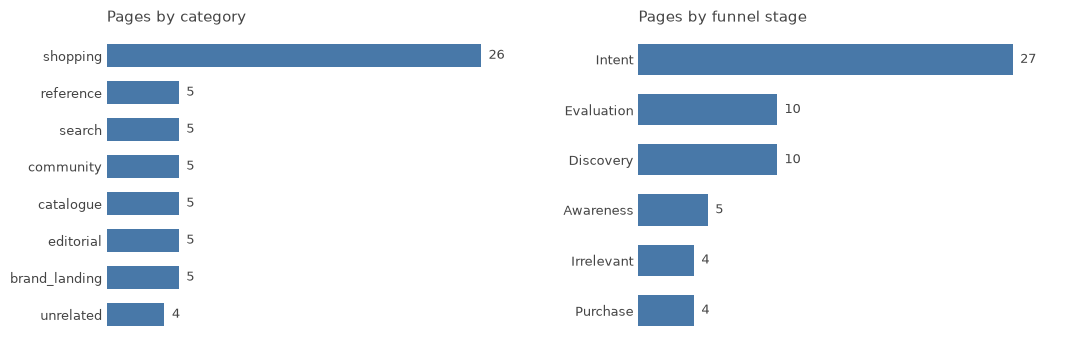

seller_type,brand_owned,na,retailer
page_category,,,
brand_landing,5,0,0
catalogue,0,0,5
community,0,5,0
editorial,0,5,0
reference,0,5,0
search,0,5,0
shopping,13,0,13
unrelated,0,2,2


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
barh(axes[0], pages["page_category"].value_counts(), "Pages by category")
barh(axes[1], pages["funnel_stage"].value_counts(), "Pages by funnel stage")
plt.tight_layout(); plt.show()
display(pd.crosstab(pages["page_category"], pages["seller_type"]))

## 4 · Service routing — one domain is not one thing

The bug this fixes: `google` sat in the search-domain list, so **every**
Google URL voted "search" — `docs.google.com` documents, Maps, account
sign-ins, all of it. Now `_PLATFORM_SERVICES` routes multi-service platforms
(Google, Bing, Yahoo, Amazon, Facebook, Instagram, YouTube, X, Apple,
Microsoft) by **subdomain + first path segment** *before* any domain vote:

* the matched service's verdict **replaces** the generic domain vote;
* an *unrecognized* service on a strict platform gets **no domain opinion at
  all** — honest `unknown`, never a false "search";
* marketplace **surfaces** stay topic-neutral journey infrastructure, but
  deep *item* pages demote to `listing` so fetched off-topic listings can
  still collapse to `unrelated`;
* two-letter locale subdomains (`cn.bing.com`) stay transparent.

The `service` entry in `classification_signals` makes every routed page
auditable.

In [5]:
from conveyer.scraping import classify_url

routing_demo = [
    "https://www.google.com/search?q=best+retinol",   # the actual search engine
    "https://www.google.com/",                        # engine root
    "https://docs.google.com/document/d/abc/edit",    # a document, not search
    "https://drive.google.com/file/d/xyz/view",
    "https://accounts.google.com/signin/v2",          # auth wall
    "https://maps.google.com/maps/place/Sephora",     # places surface
    "https://news.google.com/stories/xyz",            # editorial
    "https://support.google.com/mail/answer/1",       # help center
    "https://shopping.google.com/",                   # marketplace SURFACE (neutral)
    "https://shopping.google.com/product/123",        # deep item -> listing
    "https://www.google.com/randomservice/thing",     # unknown surface: no false 'search'
    "https://aws.amazon.com/s3/",                     # amazon != retail here
    "https://www.amazon.com/dp/B00X",                 # ...but www stays a retailer
    "https://www.facebook.com/marketplace",           # neutral surface
    "https://www.facebook.com/marketplace/item/9",    # deep item -> listing
    "https://cn.bing.com/",                           # locale subdomain = the engine
]
pd.DataFrame([{
    "url": u, "category": c.page_category, "subtype": c.page_subtype,
    "funnel": c.funnel_stage, "signals": ", ".join(c.signals),
} for u in routing_demo for c in [classify_url(u, cfg)]])

,url,category,subtype,funnel,signals
0,https://www.google.com/search?q=best+retinol,search,serp,Intent,"url, service, model"
1,https://www.google.com/,search,serp,Intent,"url, service, model"
2,https://docs.google.com/document/d/abc/edit,unrelated,tool,Irrelevant,"service, model"
3,https://drive.google.com/file/d/xyz/view,unrelated,tool,Irrelevant,"service, model"
4,https://accounts.google.com/signin/v2,unrelated,account,Irrelevant,"service, model"
5,https://maps.google.com/maps/place/Sephora,reference,local,Awareness,"service, model"
6,https://news.google.com/stories/xyz,editorial,article,Evaluation,"url, service, model"
7,https://support.google.com/mail/answer/1,reference,wiki,Awareness,"service, model"
8,https://shopping.google.com/,catalogue,marketplace,Discovery,"url, service, model"
9,https://shopping.google.com/product/123,catalogue,listing,Discovery,"url, service, model"


### URL-only classification — the multimodal guarantee, revisited

Many surfaced URLs can never be fetched (bot walls, logins, carts). Any one
channel can carry a page alone; topic-neutral pages (carts, checkouts, SERPs,
storefront entries) are journey infrastructure never demoted for lacking
beauty tokens — but neutrality must be **earned** by a decisive vote.

In [6]:
from conveyer.scraping.classify import classify_rule
from conveyer.scraping.extract import extract_page

url_only = [
    "https://www.amazon.com/gp/cart/view.html?ref_=nav_cart",   # retailer cart
    "https://glowlab.myshopify.com/checkouts/c/0a1b2c3d",        # checkout on an unknown store
    "https://www.amazon.com/gp/css/order-history",               # post-purchase infrastructure
    "https://www.amazon.com/dp/B00365FJ8K",                      # opaque PDP
    "https://www.sephora.com/careers",                           # catch-all earns nothing
    "https://www.reddit.com/r/SkincareAddiction/comments/1/x",   # community
    "https://someblog-nobody-knows.xyz/post/123",                # nothing to go on
]
pd.DataFrame([{
    "url": u, "category": c.page_category, "subtype": c.page_subtype,
    "seller": c.seller_type, "funnel": c.funnel_stage,
    "relevant": c.is_study_relevant, "signals": ", ".join(c.signals),
} for u in url_only for c in [classify_rule(extract_page("", u), u, cfg)]])

,url,category,subtype,seller,funnel,relevant,signals
0,https://www.amazon.com/gp/cart/view.html?ref_=nav_cart,shopping,cart,retailer,Purchase,True,"url, domain, model"
1,https://glowlab.myshopify.com/checkouts/c/0a1b2c3d,shopping,checkout,na,Purchase,True,"url, model"
2,https://www.amazon.com/gp/css/order-history,shopping,order,retailer,Post-Purchase,True,"url, domain"
3,https://www.amazon.com/dp/B00365FJ8K,shopping,pdp,retailer,Intent,False,"url, domain, model"
4,https://www.sephora.com/careers,unknown,listing,retailer,Irrelevant,False,domain
5,https://www.reddit.com/r/SkincareAddiction/comments/1/x,community,forum,na,Evaluation,False,"domain, model"
6,https://someblog-nobody-knows.xyz/post/123,unknown,article,na,Irrelevant,False,model


## 5 · The learned model — a classifier we train ourselves

`conveyer/scraping/model.py` adds a **trainable multinomial logistic model**
over stable hashed features as one more voting channel (`"model"` in
`classification_signals`). Design:

* **features**: URL structure (domain core, subdomain, TLD, path segments and
  word-pieces, query keys), markup (schema.org types, og:type,
  price/add-to-cart, product-count bucket), text tokens (title, meta, h1,
  first words), the vendor prior and the platform fingerprint. URL-only
  variants of every page are trained too, so the model works on unfetchable
  URLs;
* **training data**: the synthetic ground truth + a *distillation* of the
  service-routing and transactional URL rules + (optionally) the confident
  rows of your own parquet as weak labels — self-training:
  `python -m conveyer.scraping.model train --pages outputs/scrape/scraped_pages.parquet`;
* **persistence**: a plain `.npz` (atomic write; corrupt files retrain);
  training needs scikit-learn, **inference needs only numpy**;
* **integration**: votes `model_weight × probability` for the top subtypes —
  *below* the decisive 2.5–3.0 rule votes, so it tips ties but cannot
  overrule a `/cart/` path; fail-open (any error ⇒ no opinion); explicitly
  **off** in the URL-rules-only validator and the smart-fetch gate.

In [7]:
from conveyer.scraping.model import PageModel, build_training_samples, evaluate_model, featurize

model = PageModel.load(cfg.model_path)
print(f"model: {len(model.classes)} subtypes x {model.dim} hashed dims "
      f"({Path(cfg.model_path).stat().st_size/1e3:.0f} KB on disk)\n")
# standalone cross-validated quality (the channel is a corroborator, not the decider)
_ = evaluate_model()

model: 15 subtypes x 65536 hashed dims (54 KB on disk)



              precision    recall  f1-score   support

     account       0.00      0.00      0.00        16
     article       0.75      0.84      0.79       102
        cart       1.00      1.00      1.00        19
    checkout       1.00      0.90      0.95        10
  collection       0.94      0.73      0.82        22
       forum       1.00      0.83      0.91        18
    homepage       1.00      0.62      0.77        16
       local       0.00      0.00      0.00         6
 marketplace       0.67      0.20      0.31        20
       order       1.00      0.90      0.95        10
         pdp       0.94      0.93      0.93       129
        serp       0.60      0.42      0.49        43
        tool       0.50      0.93      0.65       100
        wiki       0.65      0.23      0.34        48
    wishlist       1.00      0.60      0.75         5

    accuracy                           0.73       564
   macro avg       0.74      0.61      0.64       564
weighted avg       0.74   

### 5.1 Which features carry weight

Feature hashing has no stored vocabulary, but every feature *string* is
reconstructible — so we hash the training vocabulary back and read each
feature's learned coefficient per class. (Hash collisions can blend a pair of
features; with 65k dims and a few thousand features they are rare.) This is
the direct answer to *"which features seem important"*:

747 distinct features hashed into 65536 dims


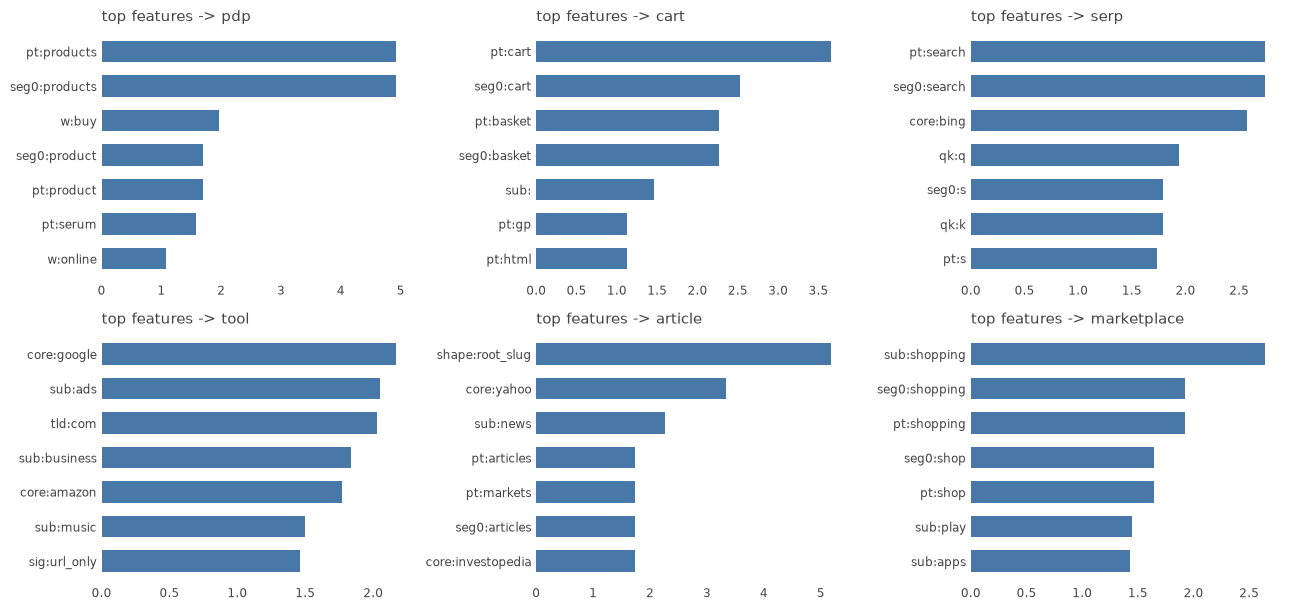

In [8]:
from conveyer.scraping.model import _hash_feature

X_feats, y = build_training_samples()          # same seed as autotrain
vocab = sorted({f for feats in X_feats for f in feats})
rows = []
for f in vocab:
    idx, sign = _hash_feature(f, model.dim)
    for ci, cls in enumerate(model.classes):
        rows.append((cls, f, float(sign * model.coef[ci, idx])))
W = pd.DataFrame(rows, columns=["subtype", "feature", "weight"])
print(f"{len(vocab)} distinct features hashed into {model.dim} dims")

show = ["pdp", "cart", "serp", "tool", "article", "marketplace"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.2))
for ax, cls in zip(axes.ravel(), show):
    top = W[W.subtype == cls].nlargest(7, "weight").sort_values("weight")
    ax.barh(top.feature, top.weight, color=HUE, height=0.62)
    ax.set_title(f"top features -> {cls}", fontsize=10.5, color=INK, loc="left")
    ax.tick_params(labelsize=8.5, colors=INK, length=0)
    for s in ("top", "right", "left", "bottom"):
        ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

In [9]:
# the strongest single features overall, whatever the class
(W.assign(absw=W.weight.abs()).nlargest(18, "absw")
 [["subtype", "feature", "weight"]].reset_index(drop=True).round(3))

,subtype,feature,weight
0,article,shape:root_slug,5.172
1,pdp,pt:products,4.921
2,pdp,seg0:products,4.921
3,cart,pt:cart,3.650
4,article,core:yahoo,3.340
5,homepage,path:root,3.265
6,wiki,sub:support,3.045
7,wiki,sub:developer,2.978
8,collection,pt:collections,2.967
9,collection,seg0:collections,2.967


## 6 · How the classifier behaves — channel ablation

Which channels actually carry the decisions? We re-classify the ground-truth
corpus with channels knocked out one at a time and read the accuracy drop.
`classification_signals` frequencies show *which channels fired where*; the
ablation shows *which ones the accuracy depends on*.

In [10]:
from conveyer.scraping.synthetic import make_corpus
from dataclasses import replace as cfg_replace

corpus = make_corpus(120, seed=42)
gt = corpus.ground_truth.set_index("url")

def classify_corpus(cfg_v, content=True):
    out = []
    for url, row in gt.iterrows():
        html = corpus.html_by_url.get(url, "") if content else ""
        prior = corpus.urls.set_index("url").loc[url]
        prior_d = {cfg_v.col_page_type: prior.get("page_type"),
                   cfg_v.col_seller_type: prior.get("seller_type"),
                   cfg_v.col_retailer_brand: prior.get("retailer_brand"),
                   cfg_v.col_site_category: prior.get("site_category")}
        c = classify_rule(extract_page(html or "", url), url, cfg_v, prior=prior_d,
                          content_scope="page" if html else "none")
        out.append({"url": url, "cat": c.page_category, "sub": c.page_subtype,
                    "signals": c.signals})
    df = pd.DataFrame(out).set_index("url")
    df["cat_ok"] = df["cat"] == gt["gt_category"]
    df["sub_ok"] = df["sub"] == gt["gt_subtype"]
    return df

variants = {
    "full (all channels)":        (cfg, True),
    "no learned model":           (cfg_replace(cfg, use_learned_model=False), True),
    "no vendor prior":            (cfg_replace(cfg, use_similarweb_prior=False), True),
    "URL/domain only (no content)": (cfg, False),
    "URL only, no model":         (cfg_replace(cfg, use_learned_model=False), False),
}
abl = pd.DataFrame([
    {"variant": name,
     "category_accuracy": classify_corpus(v, content).cat_ok.mean(),
     "subtype_accuracy": classify_corpus(v, content).sub_ok.mean()}
    for name, (v, content) in variants.items()
]).round(3)
abl

,variant,category_accuracy,subtype_accuracy
0,full (all channels),1.000,1.000
1,no learned model,1.000,0.933
2,no vendor prior,1.000,1.000
3,URL/domain only (no content),0.842,0.933
4,"URL only, no model",0.842,0.858


In [11]:
# which channels fire, per (true) category — the audit-trail view
full = classify_corpus(cfg, True).join(gt)
sig = (full.explode("signals").groupby(["gt_category", "signals"]).size()
       .unstack(fill_value=0))
sig

signals,domain,markup,model,prior,service,url
gt_category,,,,,,
brand_landing,8,8,8,8,0,8
catalogue,8,8,8,8,0,8
community,8,8,8,0,0,0
editorial,13,13,13,0,0,13
reference,5,5,5,0,0,5
search,0,5,5,0,5,5
shopping,36,32,54,32,0,54
unrelated,10,19,19,10,0,10


## 7 · Block resilience — never walk away empty-handed

Real sites bot-wall scrapers. The fetcher's posture:

* **present a browser header profile** (`browser_headers=True`) so naive
  UA-string blocks never fire — robots.txt is still checked first;
* when a wall answers anyway: **401/403/406/451 → `fetch_status="blocked"`,
  never retried** (a wall answers the same way every time; the domain's
  circuit breaker stops further contact). 429 honors `Retry-After`
  (delta-seconds or HTTP-date);
* **salvage everything the response gave us**: the headers land in
  `response_headers`, a bounded error-body excerpt is kept for
  fingerprinting only (it never masquerades as page content);
* `fingerprint.py` reads the platform from headers/markup —
  `x-shopify-stage` ⇒ Shopify ⇒ this domain is a **storefront** — which is
  exactly the "even a header is useful" idea: a bot-walled Shopify store's
  `/products/…` URL still classifies `shopping · pdp · brand_owned`. The
  platform is remembered in the domain profile, so it keeps working after
  the circuit opens. Structural evidence only: it never makes an off-topic
  store study-relevant, and it is suppressed on curated retailer domains.

In [12]:
from conveyer.scraping.fingerprint import detect_platform, platform_seller

blocked_headers = {"server": "cloudflare", "x-shopify-stage": "production",
                   "content-type": "text/html"}
plat = detect_platform(blocked_headers, "<html>Access denied</html>")
print(f"fingerprint from a 403's headers: {plat!r}  (seller hint: {platform_seller(plat)!r})")

blocked_url = "https://an-unknown-store.example/products/vitamin-c-serum"
c = classify_rule(extract_page("", blocked_url), blocked_url, cfg,
                  content_scope="none", platform=plat)
print(f"bot-walled shopify PDP -> {c.page_category} · {c.page_subtype} · "
      f"{c.seller_type} · signals={c.signals}")

# ...but an OFF-TOPIC store with fetched content still collapses: the
# fingerprint is structural, not topical
offtopic = ('<html lang="en"><head><title>Apex Gaming Gear</title></head>'
            '<body><h1>Mechanical keyboards</h1><p>RGB switches. $120.</p></body></html>')
c2 = classify_rule(extract_page(offtopic, "https://apexgear.example/"),
                   "https://apexgear.example/", cfg, platform="shopify")
print(f"off-topic shopify homepage -> {c2.page_category} (relevant={c2.is_study_relevant})")

fingerprint from a 403's headers: 'shopify'  (seller hint: 'brand_owned')
bot-walled shopify PDP -> shopping · pdp · brand_owned · signals=['url', 'platform', 'model']
off-topic shopify homepage -> unrelated (relevant=False)


## 8 · Topical relevance — a separate axis, and retroactive repair

`skincare_relevance` (name kept for schema stability) scores the whole
**beauty / personal-care** umbrella — skincare, haircare, bodycare, cosmetics
— in content **and** URL slugs. Every term must be unambiguous at a single
hit ("air conditioner" never counts). Extend per run:
`ScrapeConfig(extra_relevance_terms=("beard oil",))`.

Because labels are burned in at scrape time and `resume` never revisits done
URLs, vocabulary improvements come with a **retroactive rescue** that re-runs
the classifier from the cached HTML (`html_path`) — no re-scraping:

```bash
python -m conveyer.scraping.validate outputs/scrape/scraped_pages.parquet --reclassify          # preview
python -m conveyer.scraping.validate outputs/scrape/scraped_pages.parquet --reclassify --apply  # rescue in place
python -m conveyer.scraping.validate outputs/scrape/scraped_pages.parquet --apply               # URL-rule repair
```

In [13]:
hair_url = "https://www.jbca.com/products/thickening-strengthening-restorative-conditioner"
hair = classify_rule(extract_page("", hair_url), hair_url, cfg)
beard = ScrapeConfig(extra_relevance_terms=("beard oil",), use_learned_model=False)
b_url = "https://groomedman.example/products/cedar-beard-oil"
b0 = classify_rule(extract_page("", b_url), b_url, ScrapeConfig(use_learned_model=False))
b1 = classify_rule(extract_page("", b_url), b_url, beard)
print(f"haircare slug alone      -> relevance {hair.skincare_relevance} (relevant={hair.is_study_relevant})")
print(f"beard oil, default vocab -> relevant={b0.is_study_relevant} | "
      f"with extra_relevance_terms -> relevant={b1.is_study_relevant}")

haircare slug alone      -> relevance 0.25 (relevant=True)
beard oil, default vocab -> relevant=False | with extra_relevance_terms -> relevant=True


## 9 · Products, matched to the chat — precision-first tiers

Product metadata comes from schema.org JSON-LD → OpenGraph → microdata →
visible-price heuristic (`extraction_source`). Each product is scored against
the mentions of the turns that surfaced the page; the verdict is a **tier**
(`match_strength`), and only `exact` / `strong` may set `coincides`:

* **exact** — SKU identity, or brand agreement + near-identical name;
* **strong** — brand + name corroboration (core-token containment /
  char-trigram similarity — typo-robust), or a near-identical multi-token
  name with no brand info;
* **likely** — brand alone, or a shared form/category word alone — the same
  *brand* is not the same *product*; **never coincides**;
* vetoes: brand conflict (Cetaphil ≠ CeraVe), attribute conflict (SPF 30 ≠
  SPF 60; a *lotion* is not the *cream* — with synonym groups so
  "face wash" ≡ "cleanser").

Long-tail brands connect via `brand_in_entity`: a JBCA conditioner PDP links
to "the JBCA thickening conditioner" even though no lexicon knows the brand.
`match_signals` records which evidence fired; the page-grain roll-up is
`chat_match_strength` / `chat_match_score`.

In [14]:
from conveyer.scraping.products import ProductRecord, RecMention, match_products

mention = RecMention(recommendation_id="r1", message_id="m1",
                     entity_context="CeraVe Moisturizing Cream — a rich moisturizer "
                                    "the assistant recommended",
                     brands={"cerave"}, categories={"moisturizer"})
jbca_mention = RecMention(recommendation_id="r2", message_id="m1",
                          entity_context="the JBCA thickening strengthening conditioner",
                          brands=set(), categories={"conditioner"})
demo = [
    ProductRecord(name="CeraVe Moisturizing Cream 19 oz", brand="CeraVe", price=16.99),
    ProductRecord(name="CereVe Moisturising Cream", brand="", price=16.0),          # typo
    ProductRecord(name="CeraVe Foaming Facial Cleanser", brand="CeraVe", price=15.0),  # sibling
    ProductRecord(name="CeraVe Eye Repair Cream", brand="CeraVe", price=14.0),      # same form, wrong product
    ProductRecord(name="Cetaphil Moisturizing Cream", brand="Cetaphil", price=13.0),   # rival
    ProductRecord(name="Thickening Strengthening & Restorative Conditioner",
                  brand="JBCA Cosmetics", price=6.99),                              # long-tail brand
]
match_products(demo, page_brand="", mentions=[mention, jbca_mention], message_id="m1")
pd.DataFrame([{
    "product": p.name, "tier": p.match_strength, "score": p.match_score,
    "coincides": p.coincides, "signals": ", ".join(p.match_signals),
} for p in demo])

,product,tier,score,coincides,signals
0,CeraVe Moisturizing Cream 19 oz,exact,1.0000,True,"brand_lexicon, attr_agree, name_containment, name_ngram"
1,CereVe Moisturising Cream,strong,0.7478,True,"attr_agree, name_ngram"
2,CeraVe Foaming Facial Cleanser,likely,0.4500,False,"brand_lexicon, attr_conflict"
3,CeraVe Eye Repair Cream,likely,0.4500,False,"brand_lexicon, attr_agree"
4,Cetaphil Moisturizing Cream,likely,0.3000,False,"brand_conflict, attr_agree, name_containment, name_ngram"
5,Thickening Strengthening & Restorative Conditioner,exact,0.9656,True,"brand_in_entity, attr_agree, name_containment, name_ngram"


In [15]:
print(products["match_strength"].value_counts().to_string(), "\n")
print(f"coincides: {int(products['coincides'].sum())}/{len(products)} products\n")
print("page-grain roll-up:")
print(pages["chat_match_strength"].value_counts().to_string())

match_strength
exact     24
likely    19
strong     5
none       5 

coincides: 29/53 products

page-grain roll-up:
chat_match_strength
none      32
exact     20
likely     8


## 10 · Attention ranking — dwell time from the browsing trail

`next_10_urls` timestamps give each page's dwell (gap to the next request —
the last trail entry never gets one). `mean_trail_position` says how early
after the answer the page appears. Long dwell + early position on a
`shopping` page is the strongest behavioural signal short of a purchase flag.

In [16]:
trail = pages[pages["mean_dwell_seconds"].notna()]
rank_cols = ["url", "page_category", "funnel_stage", "times_visited",
             "mean_dwell_seconds", "total_dwell_seconds", "mean_trail_position"]
display(trail.sort_values("total_dwell_seconds", ascending=False)[rank_cols].head(8))
(trail.groupby("page_category")["mean_dwell_seconds"]
 .agg(["count", "mean", "median"]).round(1).sort_values("mean", ascending=False))

,url,page_category,funnel_stage,times_visited,mean_dwell_seconds,total_dwell_seconds,mean_trail_position
59,https://en.wikipedia.org/wiki/Cleanser,reference,Awareness,25,48.680,1217.000,8.17
2,https://www.amazon.com/products/cerave-moisturizing-cream,shopping,Intent,25,36.287,907.175,8.40
18,https://www.google.com/search?q=best+serum+for+dry+skin,search,Intent,27,30.613,826.551,8.06
14,https://www.theordinary.com/products/the-ordinary-niacin...,shopping,Intent,13,63.146,820.898,6.09
3,https://www.amazon.com/collections/moisturizers,catalogue,Discovery,27,25.047,676.269,1.57
40,https://www.paulaschoice.com/products/paula's-choice-2-b...,shopping,Intent,16,34.975,559.600,3.62
43,https://www.byrdie.com/best-exfoliants-for-dry-skin,editorial,Evaluation,29,18.992,550.768,3.84
56,https://www.allure.com/best-cleansers-for-dry-skin,editorial,Evaluation,27,19.277,520.479,4.77


,count,mean,median
page_category,,,
reference,4,26.7,23.3
editorial,5,22.9,19.3
unrelated,3,22.9,16.6
shopping,26,19.5,18.0
search,3,17.4,14.3
community,5,17.1,13.5
catalogue,5,12.7,12.0
brand_landing,5,8.7,6.9


## 11 · Self-evaluation

The synthetic corpus ships ground truth — including matcher **hard
negatives** (a same-brand different product; a rival brand's same product
line) that the old brand-only scorer would have failed. Read this as a test
of the plumbing and rules, not real-world accuracy.

In [17]:
art["evaluation"]

{'n': 60.0,
 'category_accuracy': 1.0,
 'seller_accuracy': 1.0,
 'coincide_accuracy': 1.0,
 'coincide_precision': 1.0,
 'coincide_recall': 1.0}

## 12 · Running it for real

```bash
# polite + block-resilient online run from the raw input file
python -m conveyer.scraping --clickstream-dir data/conversations.parquet \
    --online --max-urls 2000 --hard-timeout 30 --progress-every 50

# interrupted? same command again — resumes from the JSONL
# self-train the model on your accumulated real rows, then re-run
python -m conveyer.scraping.model train --pages outputs/scrape/scraped_pages.parquet
python -m conveyer.scraping.model eval

# retroactive repairs on an existing parquet (no re-scrape)
python -m conveyer.scraping.validate outputs/scrape/scraped_pages.parquet --apply              # URL rules
python -m conveyer.scraping.validate outputs/scrape/scraped_pages.parquet --reclassify --apply # content-aware
```

| knob | default | meaning |
|---|---|---|
| `offline` | `True` | never touch the network |
| `browser_headers` | `True` | realistic Chrome profile; robots.txt still honored |
| `timeout` / `hard_timeout` | 10s / 30s | socket timeout · wall-clock cap per URL |
| `fetch_policy` / `max_fetch_per_domain` | `smart` / 25 | skip URL-decided pages; cap per-domain fetches |
| `domain_failure_threshold` | 3 | circuit breaker (blocks count as failures) |
| `use_learned_model` / `model_weight` | `True` / 2.0 | the self-trained channel and its vote scale |
| `model_path` / `model_autotrain` | `outputs/page_model.npz` / `True` | weights file; train-once-if-missing |
| `extra_relevance_terms` | `()` | extend the topical vocabulary per run |
| `use_similarweb_prior` / `prior_weight` | `True` / 0.5 | vendor `page_type` prior |
| `classifier` | `auto` | + LLM refinement when `ANTHROPIC_API_KEY` is set |
| `coincide_threshold` | 0.5 | score gate (tier gate always applies) |

**Known limits.** JS-rendered storefronts need a headless browser (plug
Playwright into `Fetcher.fetch`); the learned model is only as good as its
labels — feed it your real parquet as it grows; matching is dormant without
the entity tables (`fact_ai_recommendation` / `fact_ai_concept`).